In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/datos_finales.csv")

In [3]:
df["region"] = df["pais"].apply(lambda x: "España" if x == "ES" else "Resto Europa")


In [13]:
variables = df.select_dtypes(include="number").columns.tolist()


comparacion_multi = (
    df.groupby(["region", "generacion"])[variables]
      .mean()
      .round(2)
)

print(comparacion_multi)


                                      ID   edad  año_nacimiento  \
region       generacion                                           
España       baby boomers       67218.88  67.88         1956.12   
             gen x              68194.29  51.51         1972.49   
             gen z              68060.23  21.43         2002.57   
             millennials        67570.89  36.16         1987.84   
             silent generation  67588.80  83.72         1940.28   
Resto Europa baby boomers       78449.55  67.83         1955.52   
             gen x              79294.61  51.05         1972.33   
             gen z              77719.30  21.12         2002.24   
             millennials        79821.97  35.33         1988.04   
             silent generation  73323.81  82.83         1940.45   

                                años_educacion  decil_ingresos  \
region       generacion                                          
España       baby boomers                12.44            4.92 

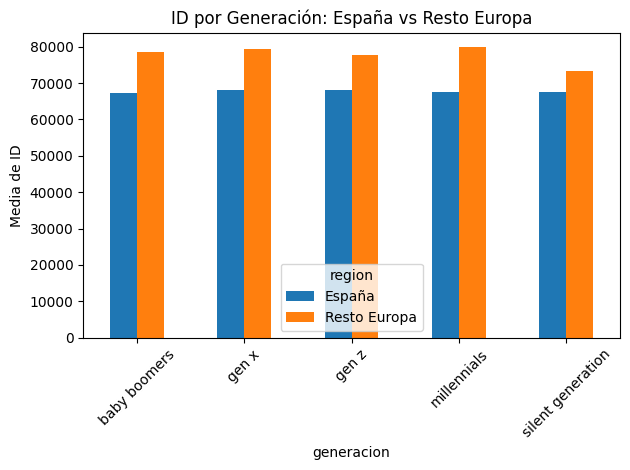

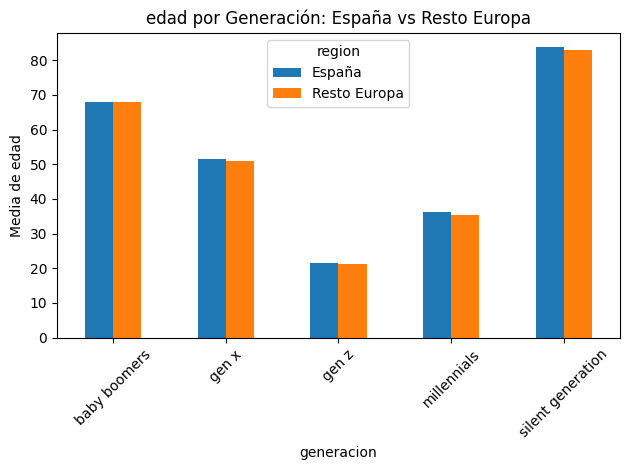

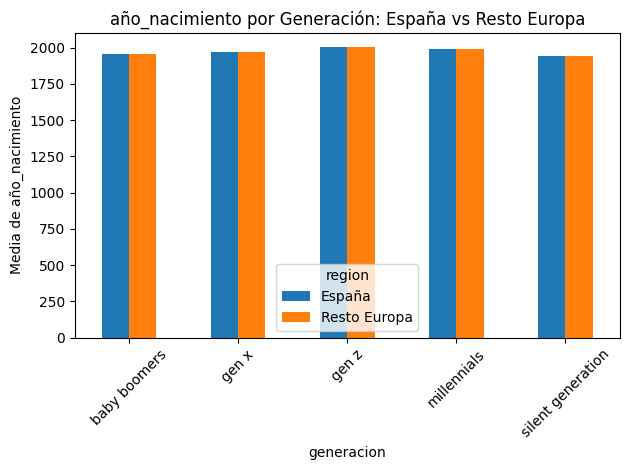

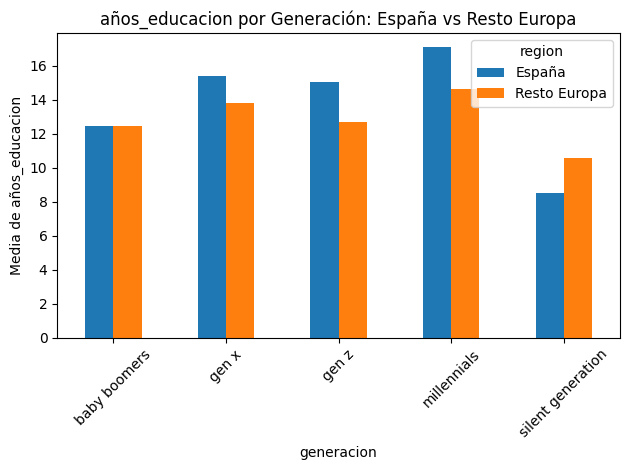

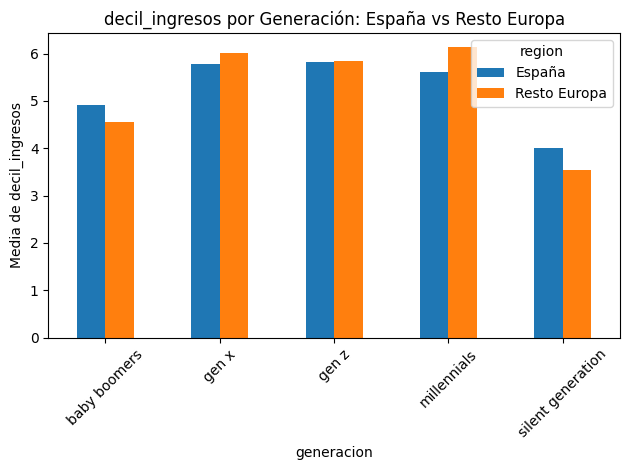

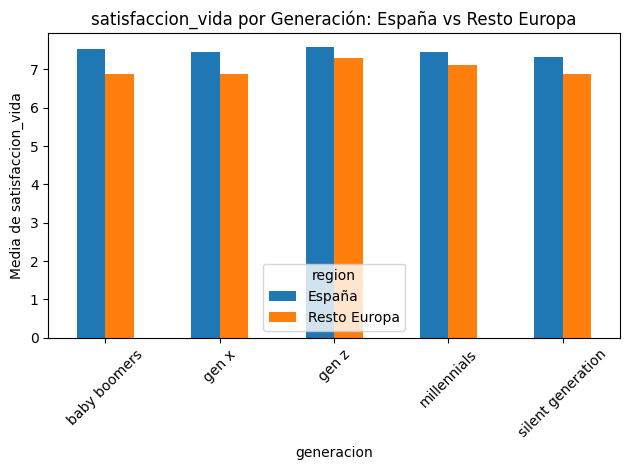

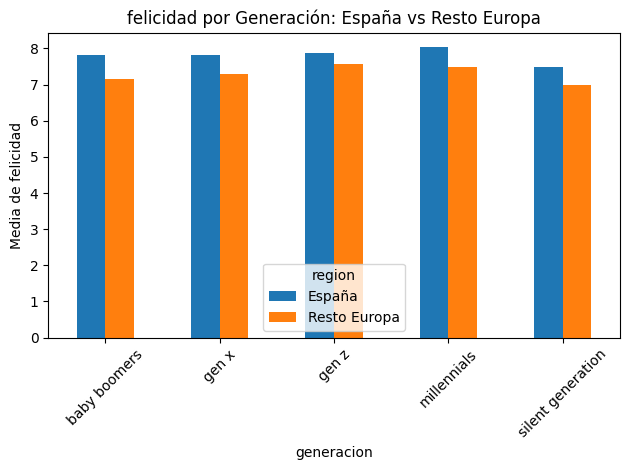

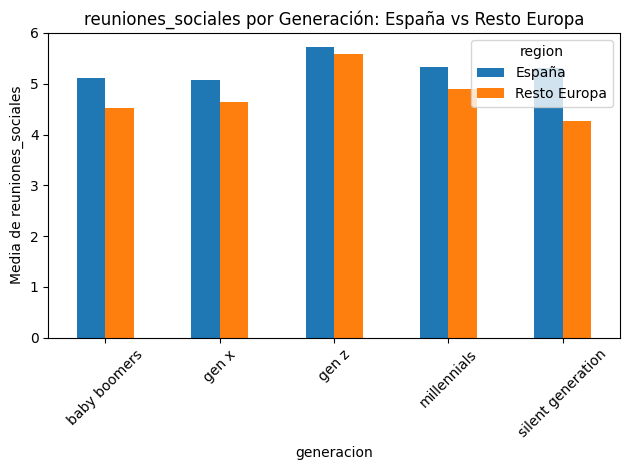

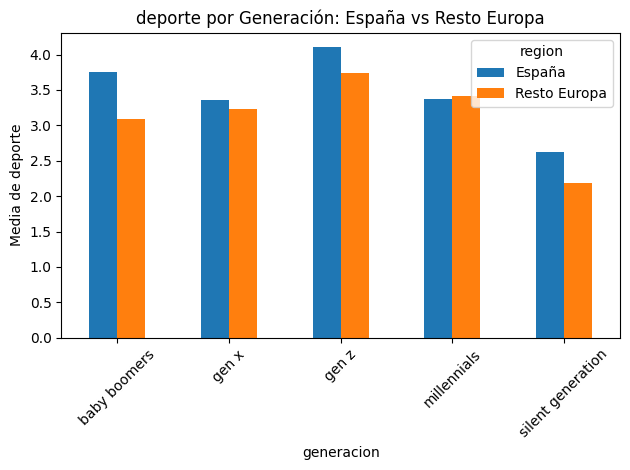

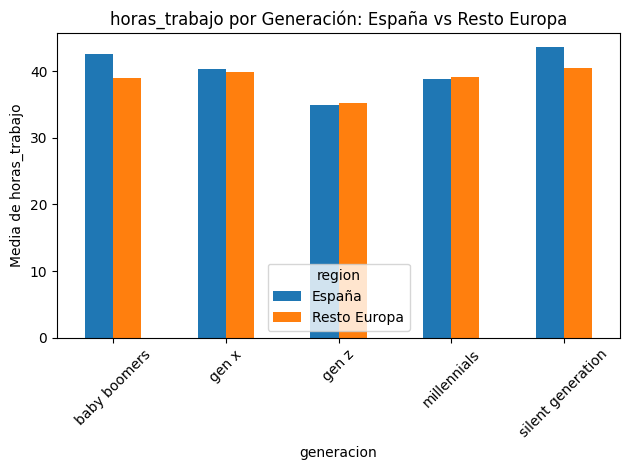

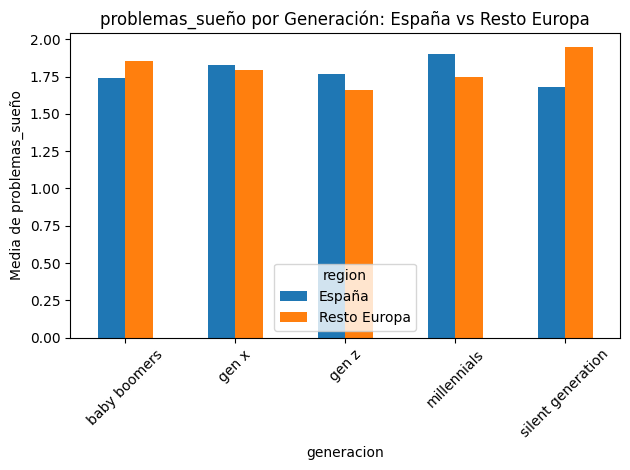

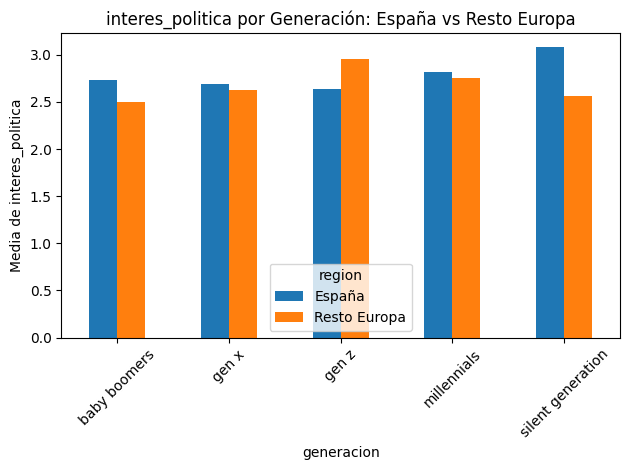

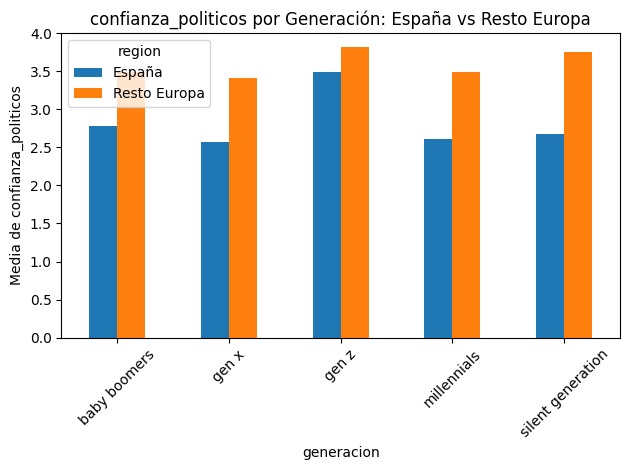

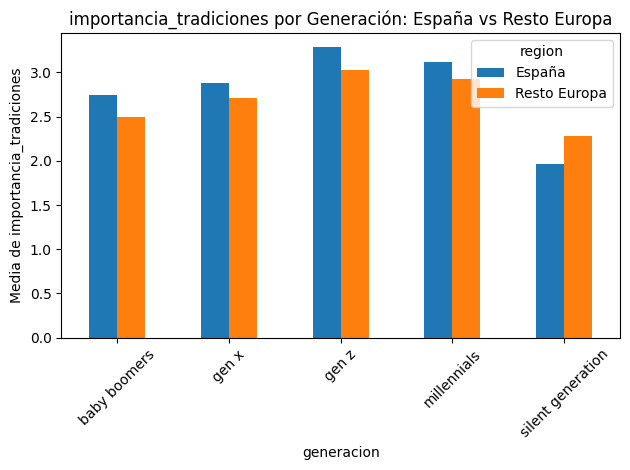

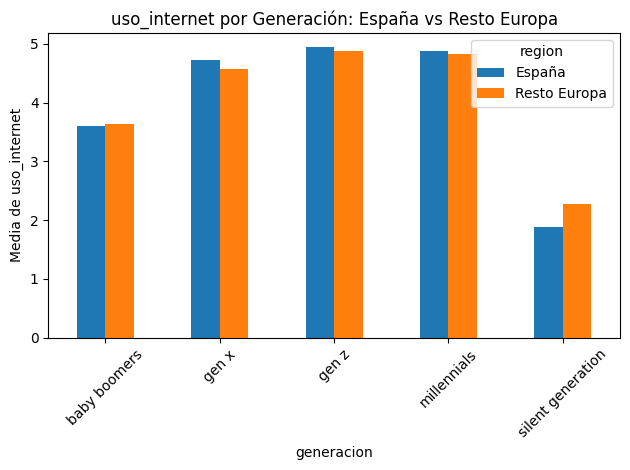

In [14]:
for variable in variables:
    
    comparacion = (
        df.groupby(["region", "generacion"])[variable]
          .mean()
          .unstack(0)
    )
    
    comparacion.plot(kind="bar")
    
    plt.ylabel(f"Media de {variable}")
    plt.title(f"{variable} por Generación: España vs Resto Europa")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()